# Sine output visualized
'sine' workflow simulates TPC evolution using a sine wave temperature data.

Daily temperature oscillates between 0 and 35 with a period = 360 days. Additionally, individual temperature fluctuates by standard deviation = 1.
Four scenarios were simulated, based on whether generation length depends on temperature or not, and whether to use a no-recovery model or recovery model.
In this notebook, we visualize on the cases where generation length is fixed to 10 days and no-recovery model is used (same as the gaussian example). 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy import signal
import sys
import pandas as pd
sys.path.insert(1, '../scripts/03_analytical_prediction')
from tpc_functions_oo import *
tpc_object = tpc_functions()
import tskit
from matplotlib.lines import Line2D
datadir = "../data/"
plt.rcParams.update({'font.size': 15})

## Load tree-sequence, log file, and analytical information

In [2]:
ts = tskit.load(f"{datadir}sine_RECOVERY_F_GEN_LEN_DEPENDS_ON_TEMP_F.trees")
metadata = ts.metadata['SLiM']['user_metadata']
Bs_final = np.array(metadata['Bs_final'])
CTmins_final = np.array(metadata['CTmins_final'])
log = pd.read_csv(f"{datadir}sine_RECOVERY_F_GEN_LEN_DEPENDS_ON_TEMP_F.txt")
analytical_info = np.load(f"{datadir}sine_RECOVERY_F_GEN_LEN_DEPENDS_ON_TEMP_F_analytical_info.npz")

In [3]:
# Use only the last 10 years of the data (1 yr = 360 days in this example)
log['day_from_end_of_sim'] = log.day - max(log.day)
log2 = log[log.day_from_end_of_sim > - 3601]

## What's expected from analytical prediction?

Average B and CTmin oscillates in a limit circle for the last 10 years of simulation. (Although the amplitude is quite small)
Analytical expected optimum is outside that orbit.

Text(0.5, 1.0, 'Background color based on expected fitness')

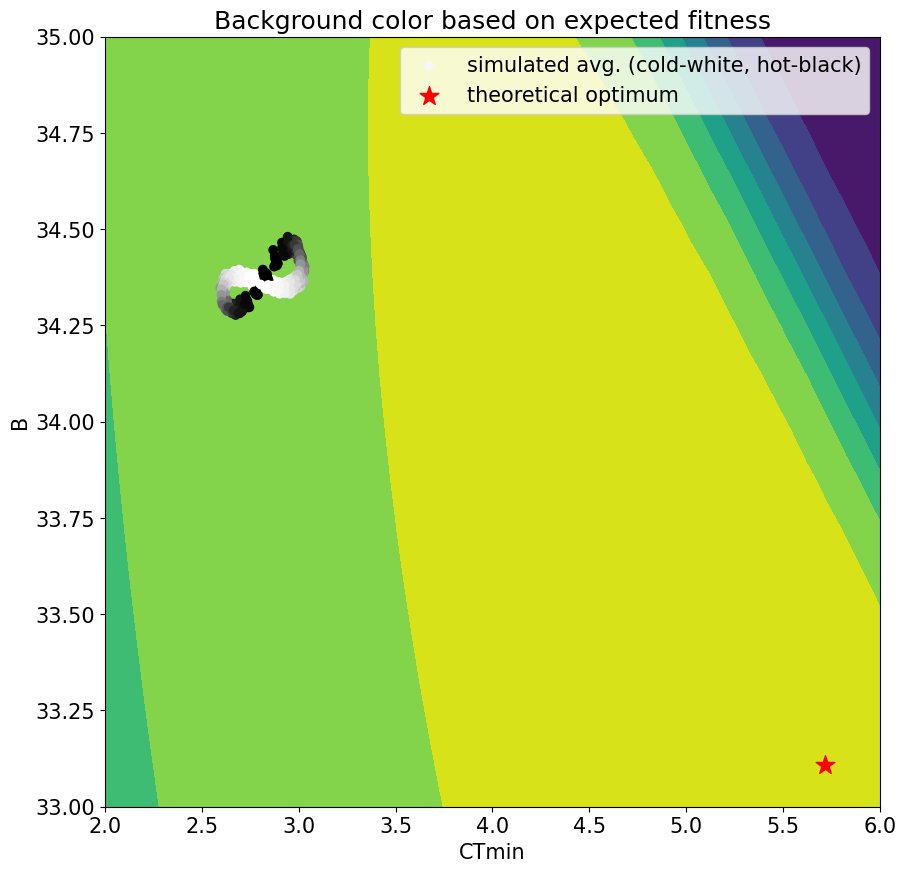

In [4]:
fig, ax = plt.subplots(1,1,figsize=(10,10))
contour = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'])
ax.scatter(log2.CTmin_mean, log2.B_mean, c=log2.Temp, cmap='Greys', vmax=35, vmin=0, label='simulated avg. (cold-white, hot-black)')

ax.scatter(analytical_info['CTmin_opt'], analytical_info['B_opt'], color='r', marker='*', label="theoretical optimum", s = 200)

ax.set_xlim((2,6))
ax.set_ylim((33, 35))
ax.set_xlabel("CTmin")
ax.set_ylabel("B")
ax.legend()
ax.set_title("Background color based on expected fitness")

## Temperature data over time
Plotting only the last 2 years.

Text(0, 0.5, 'Temperature')

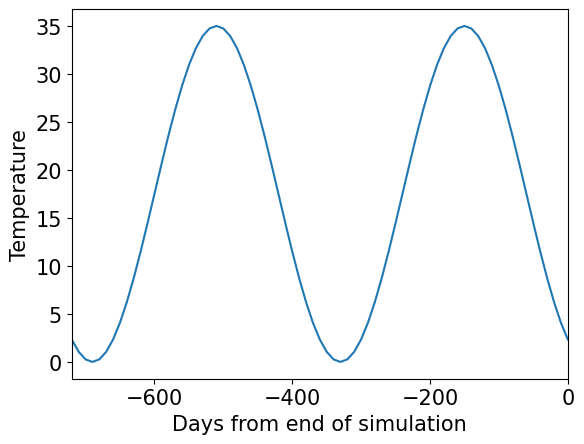

In [5]:
plt.plot(log2.day_from_end_of_sim, log2.Temp)
plt.xlim((-720, 0))
plt.xlabel("Days from end of simulation")
plt.ylabel("Temperature")

## Average TPC parameter over time

Plotting only the last 2 years. Notice shapes are not exactly sinusoidal, and response is delayed.

Text(0, 0.5, '$\\overline{B}$')

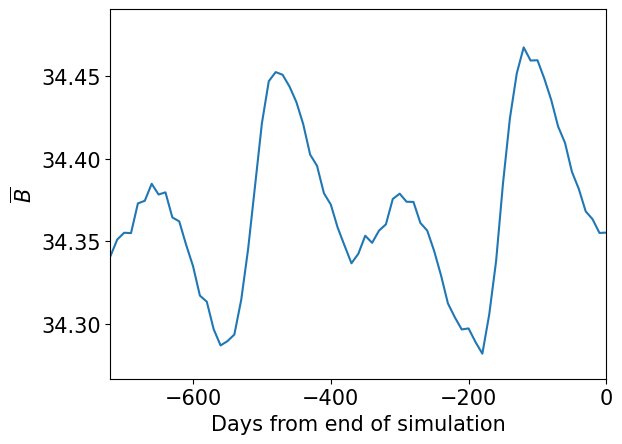

In [6]:
plt.plot(log2.day_from_end_of_sim, log2.B_mean)
plt.xlim((-720, 0))
plt.xlabel("Days from end of simulation")
plt.ylabel(r"$\overline{B}$")

Text(0, 0.5, '$\\overline{CTmin}$')

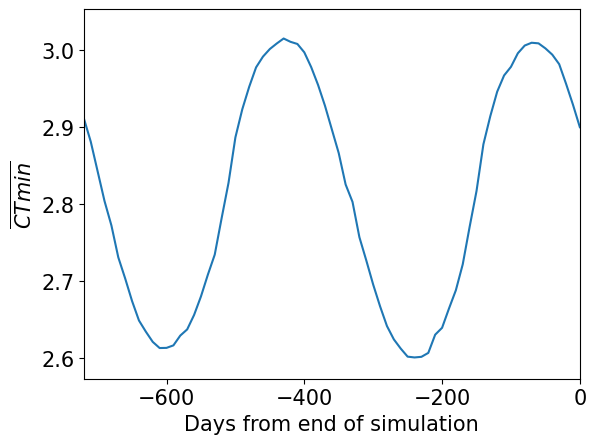

In [7]:
plt.plot(log2.day_from_end_of_sim, log2.CTmin_mean)
plt.xlim((-720, 0))
plt.xlabel("Days from end of simulation")
plt.ylabel(r"$\overline{CTmin}$")

Text(0, 0.5, '$\\overline{Topt}$')

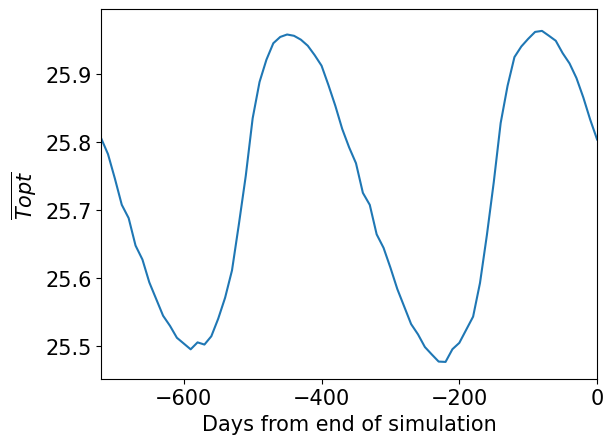

In [8]:
plt.plot(log2.day_from_end_of_sim, log2.Topt_mean)
plt.xlim((-720, 0))
plt.xlabel("Days from end of simulation")
plt.ylabel(r"$\overline{Topt}$")

Text(0, 0.5, '$\\overline{CTmax}$')

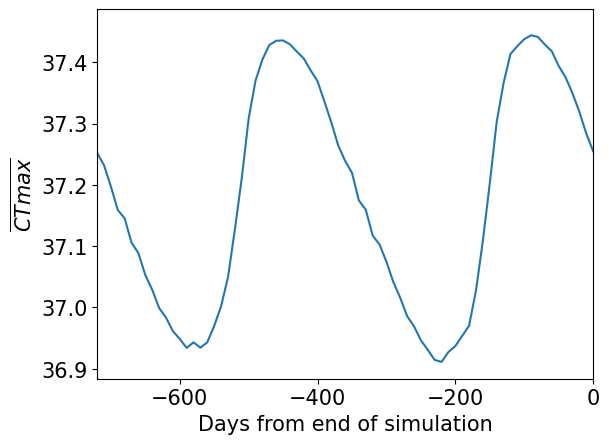

In [9]:
plt.plot(log2.day_from_end_of_sim, log2.CTmax_mean)
plt.xlim((-720, 0))
plt.xlabel("Days from end of simulation")
plt.ylabel(r"$\overline{CTmax}$")

Text(0, 0.5, 'fitness')

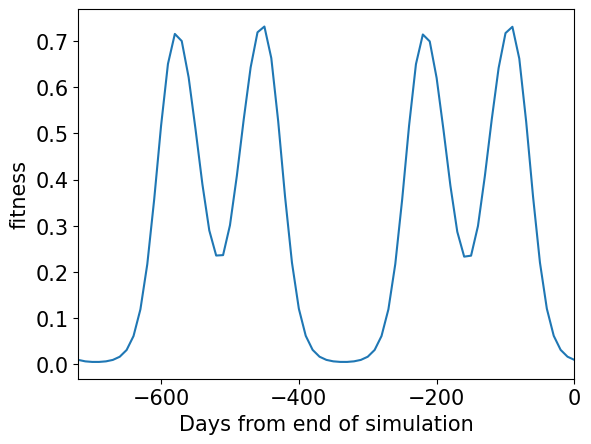

In [10]:
plt.plot(log2.day_from_end_of_sim, log2.fitness_mean)
plt.xlim((-720, 0))
plt.xlabel("Days from end of simulation")
plt.ylabel("fitness")

## Quantify the lag in CTmin and CTmax
Using `scipy.signal.find_peaks`, we find when CTmin, CTmax, and Temperature are minimized or maximized for the past 10 years of the simulation. 
CTmin is minimized about 8.6 generations (= 86 days) after the temperature is minimized. 

In [11]:
Temp_maxs = scipy.signal.find_peaks(log2.Temp, distance = 10)[0]
CTmin_maxs = scipy.signal.find_peaks(log2.CTmin_mean, distance = 10, height=log2.CTmin_mean.mean())[0]
CTmax_maxs = scipy.signal.find_peaks(log2.CTmax_mean, distance = 10, height=log2.CTmax_mean.mean())[0]

Temp_mins = scipy.signal.find_peaks(-log2.Temp, distance = 10)[0]
CTmin_mins = scipy.signal.find_peaks(-log2.CTmin_mean, distance = 10, height=-log2.CTmin_mean.mean())[0]
CTmax_mins = scipy.signal.find_peaks(-log2.CTmax_mean, distance = 10, height=-log2.CTmax_mean.mean())[0]


Verify the peaks and valleys are accurately identified.

Text(0, 0.5, 'Temperature')

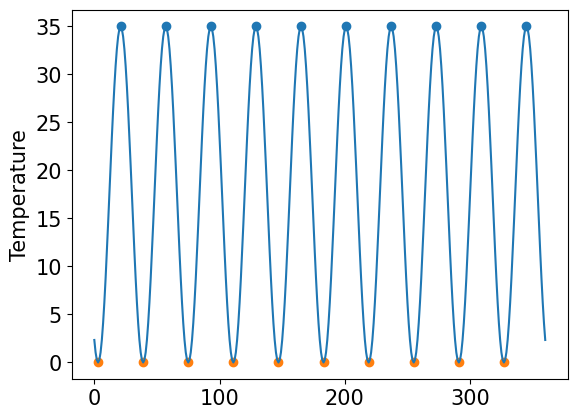

In [12]:
plt.plot(log2.Temp.reset_index(drop=True))
plt.scatter(Temp_maxs, log2.Temp.reset_index(drop=True).loc[Temp_maxs])
plt.scatter(Temp_mins, log2.Temp.reset_index(drop=True).loc[Temp_mins])
plt.ylabel("Temperature")

Text(0, 0.5, '$\\overline{CTmin}$')

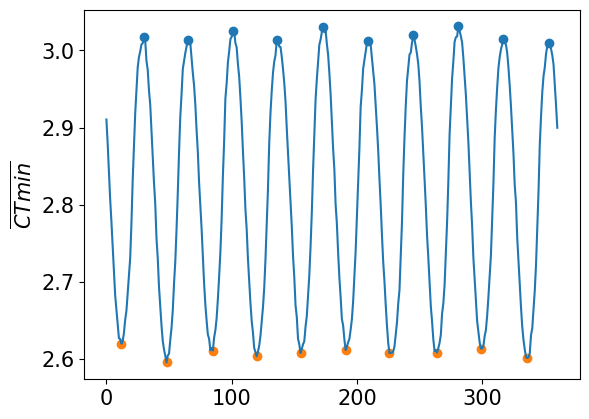

In [13]:
plt.plot(log2.CTmin_mean.reset_index(drop=True))
plt.scatter(CTmin_maxs, log2.CTmin_mean.reset_index(drop=True).loc[CTmin_maxs])
plt.scatter(CTmin_mins, log2.CTmin_mean.reset_index(drop=True).loc[CTmin_mins])
plt.ylabel(r"$\overline{CTmin}$")

Text(0, 0.5, '$\\overline{CTmax}$')

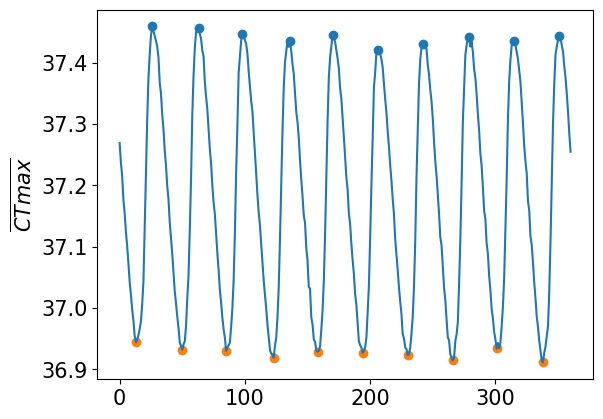

In [14]:
plt.plot(log2.CTmax_mean.reset_index(drop=True))
plt.scatter(CTmax_maxs, log2.CTmax_mean.reset_index(drop=True).loc[CTmax_maxs])
plt.scatter(CTmax_mins, log2.CTmax_mean.reset_index(drop=True).loc[CTmax_mins])
plt.ylabel(r"$\overline{CTmax}$")

In [15]:
print(f"CTmin minimized {np.mean(CTmin_mins - Temp_mins)} generations after the lowest temperature")
print(f"CTmin peaks {np.mean(CTmin_maxs - Temp_maxs)} generations after the highest temperature")

print(f"CTmax minimized {np.mean(CTmax_mins - Temp_mins)} generations after the lowest temperature")
print(f"CTmax peaks {np.mean(CTmax_maxs - Temp_maxs)} generations after the highest temperature")

CTmin minimized 8.6 generations after the lowest temperature
CTmin peaks 8.0 generations after the highest temperature
CTmax minimized 10.8 generations after the lowest temperature
CTmax peaks 5.6 generations after the highest temperature
